# ECMWF anomaly and rank

Doing the same thing as in `ecmwf_switch` but with anomaly and rank

<!-- markdownlint-disable MD013 -->

In [2]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import calendar

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
import numpy as np
import statsmodels.api as sm
from dask.diagnostics import ProgressBar
from scipy.stats import skewnorm

from src.datasources import seas5, iri, codab
from src.utils.raster import upsample_dataarray
from src.utils.rp_calc import calculate_groups_rp
from src.utils import blob_utils
from src.constants import *

In [4]:
adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)

## Process anomaly

In [5]:
da_seas5 = seas5.open_seas5_rasters()

  0%|          | 0/44 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [30]:
da_seas5_tri = da_seas5.mean(dim="lt")
da_seas5_up = upsample_dataarray(da_seas5_tri)
da_seas5_clip = da_seas5_up.rio.clip(adm1.geometry)

In [31]:
da_seas5_clip

<xarray.DataArray (year: 44, issued_month: 2, y: 38, x: 58)> Size: 776kB
dask.array<getitem, shape=(44, 2, 38, 58), dtype=float32, chunksize=(1, 1, 38, 58), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 16B 3 7
  * x             (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

(-4.6500000000099675,
 1.1499999999897028,
 11.249999999994245,
 15.049999999994029)

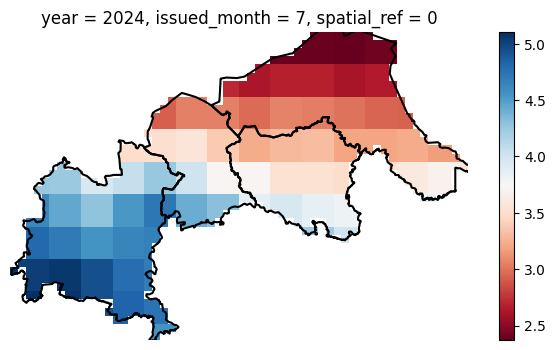

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
da_seas5_clip.isel(year=-1, issued_month=1).plot(ax=ax, cmap="RdBu")
adm1.boundary.plot(ax=ax, color="k")
ax.axis("off")

### Calculate mean

Computing and plotting things as I go just to ensure they look sensible.

In [33]:
da_seas5_mean = da_seas5_clip.mean(dim="year")

In [34]:
with ProgressBar():
    da_seas5_mean_computed = da_seas5_mean.compute()

[#############                           ] | 32% Completed | 11.27 sms


KeyboardInterrupt: 

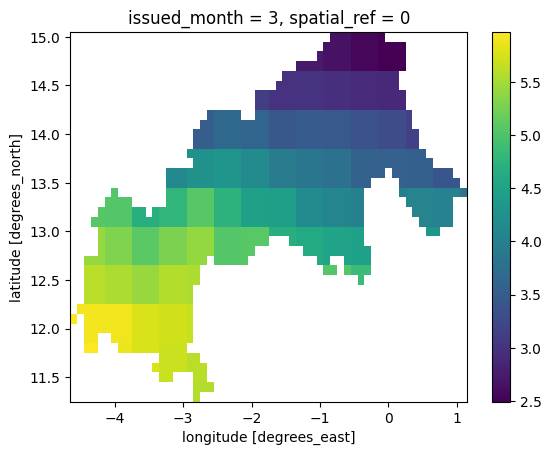

In [12]:
da_seas5_mean_computed.isel(issued_month=0).plot()

### Calculate anomaly

In [37]:
da_seas5_anomaly = (
    da_seas5_clip - da_seas5_mean_computed
) / da_seas5_mean_computed

In [38]:
with ProgressBar():
    da_seas5_anomaly_computed = da_seas5_anomaly.compute()

[########################################] | 100% Completed | 217.51 s


(-4.6500000000099675,
 1.1499999999897028,
 11.249999999994245,
 15.049999999994029)

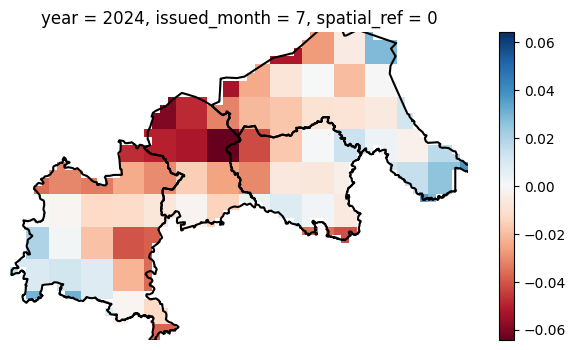

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
da_seas5_anomaly_computed.isel(year=-1, issued_month=1).plot(
    ax=ax, cmap="RdBu"
)
adm1.boundary.plot(ax=ax, color="k")
ax.axis("off")

In [42]:
da_seas5_anomaly_q = da_seas5_anomaly_computed.quantile(
    q=ORIGINAL_Q, dim=["x", "y"]
)

In [43]:
with ProgressBar():
    da_seas5_anomaly_q_computed = da_seas5_anomaly_q.compute()

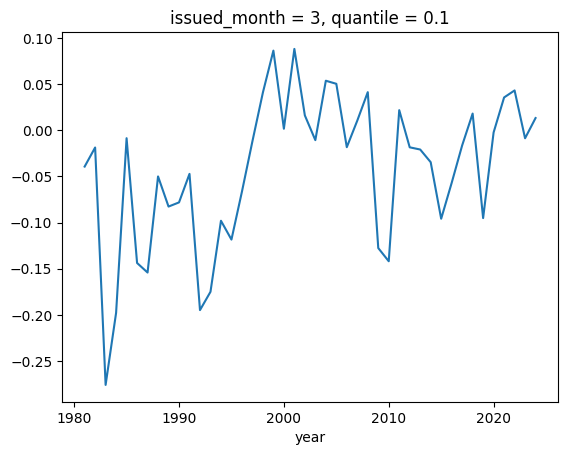

In [46]:
da_seas5_anomaly_q_computed.isel(issued_month=0).plot()

In [145]:
vmin = da_seas5_anomaly_computed.sel(year=2015, issued_month=3).min()
vmax = -vmin

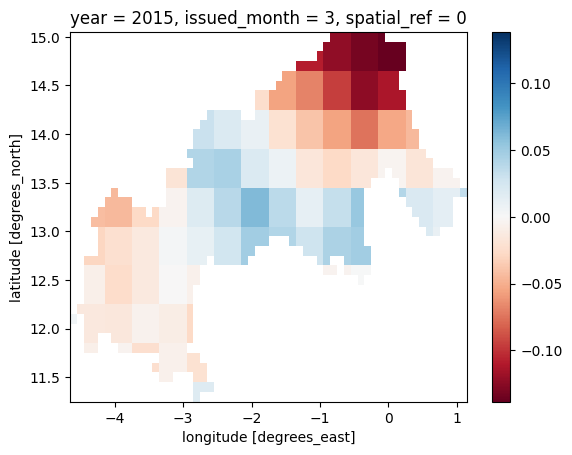

In [147]:
da_seas5_anomaly_computed.sel(year=2015, issued_month=3).plot(
    vmin=vmin, vmax=vmax, cmap="RdBu"
)

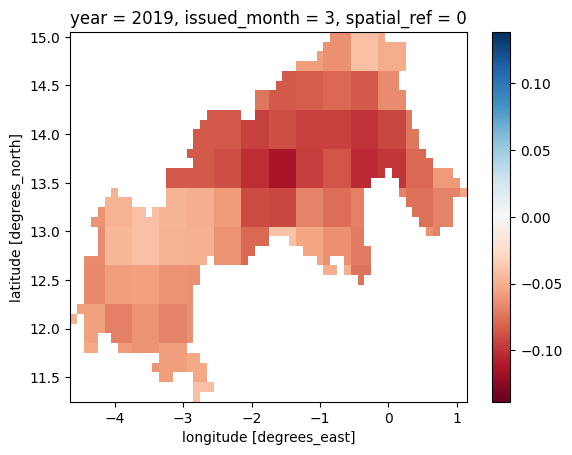

In [148]:
da_seas5_anomaly_computed.sel(year=2019, issued_month=3).plot(
    vmin=vmin, vmax=vmax, cmap="RdBu"
)

### Write to `df` and save to blob

In [47]:
df_seas5_anomaly_q = da_seas5_anomaly_q_computed.to_dataframe("q")[
    "q"
].reset_index()

<Axes: >

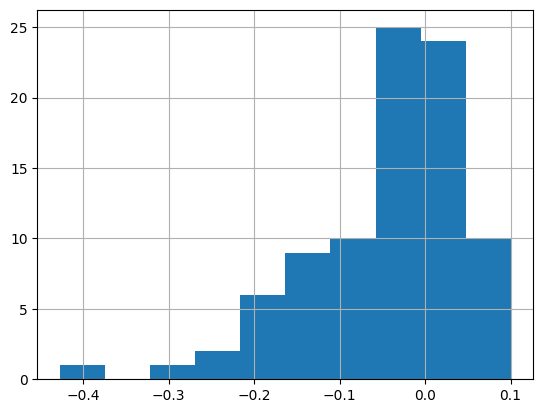

In [48]:
df_seas5_anomaly_q["q"].hist()

In [49]:
df_seas5_anomaly_q["q"].quantile(1 / 3)

-0.05777842923998839

In [50]:
df_seas5_anomaly_q

,year,issued_month,q
0,1981,3,-0.039365
1,1981,7,-0.101280
2,1982,3,-0.018709
3,1982,7,-0.166329
4,1983,3,-0.275784
...,...,...,...
83,2022,7,0.077926
84,2023,3,-0.008717
85,2023,7,0.100294
86,2024,3,0.013188


<!-- markdownlint-disable MD013 -->

In [51]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/seas5/seas5_anomaly_q10.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_seas5_anomaly_q, blob_name)

## Process rank/percentile

In [156]:
da_seas5_clip_yearchunk = da_seas5_clip.chunk({"year": -1})

In [167]:
da_seas5_rank = da_seas5_clip_yearchunk.rank(dim="year", pct=True)

In [168]:
with ProgressBar():
    da_seas5_rank_computed = da_seas5_rank.compute()

[########################################] | 100% Completed | 97.29 s


In [169]:
da_seas5_rank_computed.isel(x=20, y=1, issued_month=0)

<xarray.DataArray (year: 44)> Size: 352B
array([0.45454545, 0.18181818, 0.02272727, 0.15909091, 0.5       ,
       0.11363636, 0.22727273, 0.43181818, 0.29545455, 0.09090909,
       0.40909091, 0.06818182, 0.04545455, 0.31818182, 0.25      ,
       0.36363636, 0.38636364, 0.90909091, 1.        , 0.68181818,
       0.97727273, 0.86363636, 0.61363636, 0.77272727, 0.70454545,
       0.79545455, 0.72727273, 0.95454545, 0.13636364, 0.56818182,
       0.47727273, 0.88636364, 0.59090909, 0.34090909, 0.63636364,
       0.52272727, 0.20454545, 0.81818182, 0.27272727, 0.54545455,
       0.84090909, 0.93181818, 0.65909091, 0.75      ])
Coordinates:
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
    issued_month  int64 8B 3
    x             float64 8B -2.6
    y             float64 8B 11.4
    spatial_ref   int64 8B 0

In [172]:
vmin, vmax = 0, 1

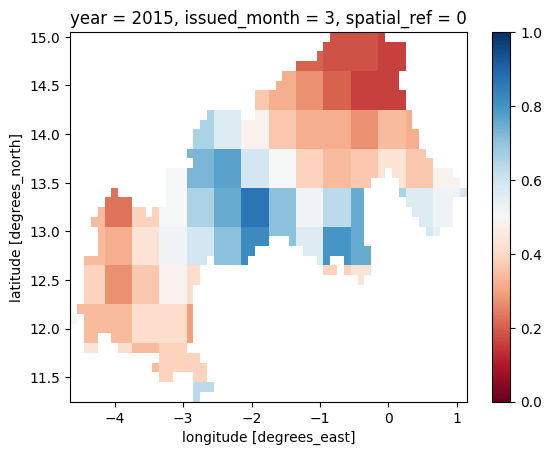

In [174]:
da_seas5_rank_computed.sel(year=2015, issued_month=3).plot(
    cmap="RdBu", vmin=vmin, vmax=vmax
)

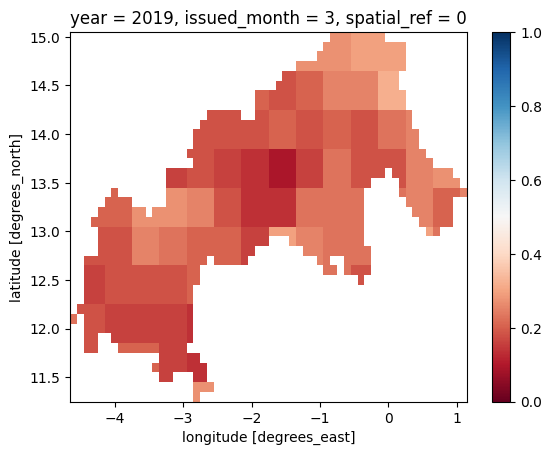

In [175]:
da_seas5_rank_computed.sel(year=2019, issued_month=3).plot(
    cmap="RdBu", vmin=vmin, vmax=vmax
)

In [183]:
da_seas5_rank_q = da_seas5_rank.quantile(q=ORIGINAL_Q, dim=["x", "y"])

In [184]:
with ProgressBar():
    da_seas5_rank_q_computed = da_seas5_rank_q.compute()

[                                        ] | 0% Completed | 3.49 s ms

[########################################] | 100% Completed | 121.95 s


In [187]:
df_seas5_rank_q = da_seas5_rank_q_computed.to_dataframe("q")["q"].reset_index()

<Axes: >

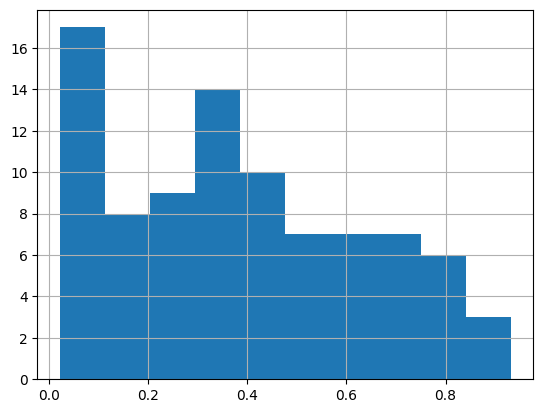

In [189]:
df_seas5_rank_q["q"].hist()

In [190]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/seas5/seas5_rank_q10.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_seas5_rank_q, blob_name)

## SEAS5 thresholds

### Loading and processing

In [8]:
df_seas5_anomaly = seas5.load_seas5_stats(variable="anomaly")

In [9]:
df_seas5_zscore = seas5.load_seas5_stats(variable="zscore")

In [10]:
df_seas5_rank = seas5.load_seas5_stats(variable="rank")

In [11]:
df_seas5_compare = df_seas5_anomaly.merge(
    df_seas5_zscore,
    suffixes=("_anomaly", "_zscore"),
    on=["issued_month", "year"],
).merge(
    df_seas5_rank.rename(columns={"q": "q_rank"}), on=["issued_month", "year"]
)
df_seas5_compare = df_seas5_compare[df_seas5_compare["year"] >= 2000]

In [12]:
df_seas5_compare

,year,issued_month,q_anomaly,q_zscore,q_rank
38,2000,3,0.001608,0.024261,0.454545
39,2000,7,0.050800,0.546936,0.681818
40,2001,3,0.088028,1.287865,0.931818
41,2001,7,-0.041080,-0.381315,0.295455
42,2002,3,0.016033,0.186523,0.568182
43,2002,7,0.011135,0.136433,0.522727
44,2003,3,-0.010740,-0.187278,0.431818
45,2003,7,-0.017346,-0.149781,0.365909
46,2004,3,0.053583,0.676953,0.727273
47,2004,7,-0.078132,-0.605415,0.250000


Quick comparison of the three metrics shows high correlation as expected.

Seems like (and I have no clue how significant this is) Z-score is a bit closer to anomaly than rank.
And both rank and anomaly are closer to Z-score than to each other.

In [9]:
for mo, group in df_seas5_compare.groupby("issued_month"):
    display(group[[x for x in df_seas5_compare.columns if "q_" in x]].corr())

,q_anomaly,q_zscore,q_rank
q_anomaly,1.000000,0.985075,0.960259
q_zscore,0.985075,1.000000,0.972029
q_rank,0.960259,0.972029,1.000000


,q_anomaly,q_zscore,q_rank
q_anomaly,1.000000,0.993184,0.962211
q_zscore,0.993184,1.000000,0.983557
q_rank,0.962211,0.983557,1.000000


<Axes: xlabel='q_anomaly'>

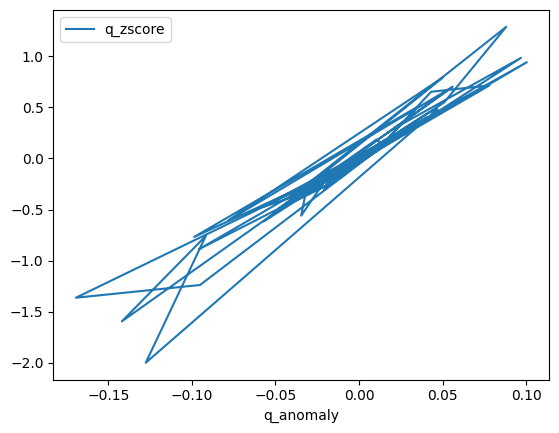

In [10]:
df_seas5_compare.plot(x="q_anomaly", y="q_zscore")

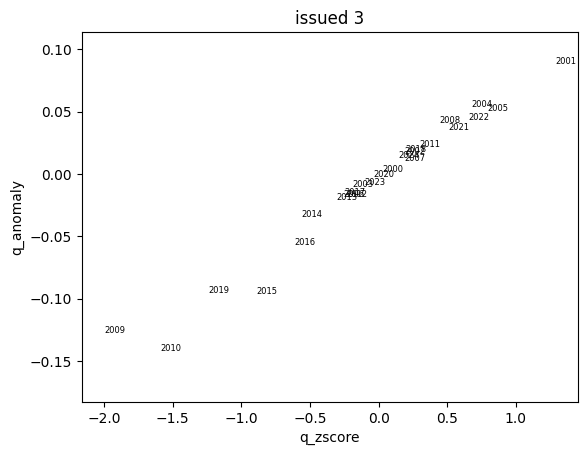

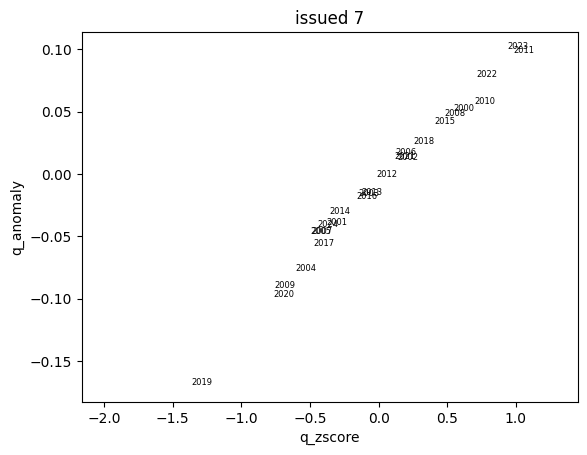

In [11]:
x_var, y_var = "q_zscore", "q_anomaly"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

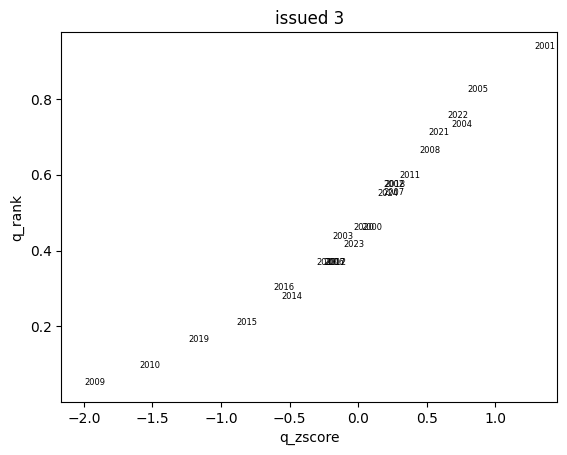

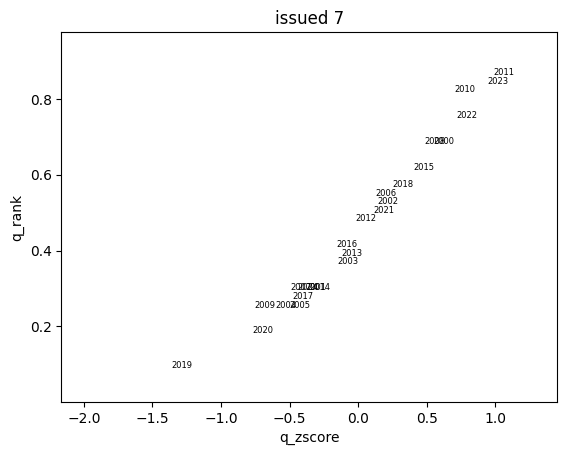

In [12]:
x_var, y_var = "q_zscore", "q_rank"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

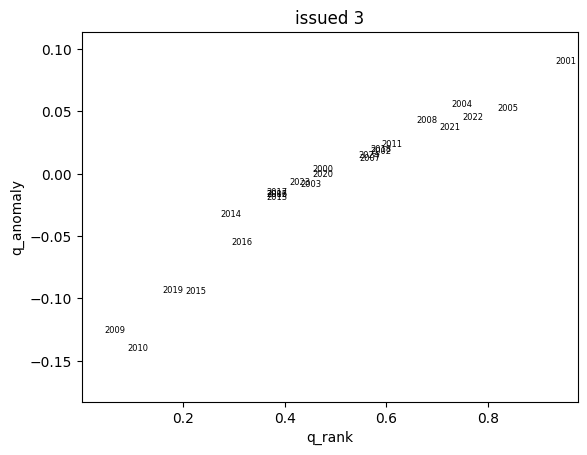

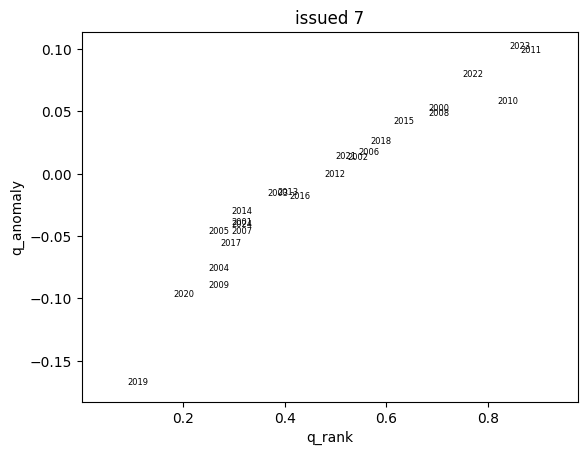

In [13]:
x_var, y_var = "q_rank", "q_anomaly"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

Next cell proceeds with rest of calculations using rank.

This is selected purely because it can argued that it's closest in meaning to the original trigger (tercile forecast), since the output is a percentile.
I think, this also fits best with the overall intent of the framework- to capture the worst historical years. The cleanest way to do that in my mind is to just take the historical rank (in percentile form), and avoids the issues of having to make any assumptions about the distribution.

In [14]:
df_seas5 = df_seas5_rank.copy()

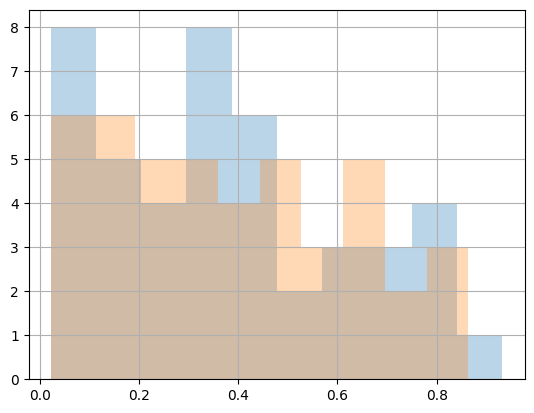

In [15]:
# just check the histogram to see that it's sensible
for issued_month, group in df_seas5.groupby("issued_month"):
    group["q"].hist(alpha=0.3)

In [16]:
df_seas5 = calculate_groups_rp(df_seas5, ["issued_month"])

In [17]:
df_pivot_rps = df_seas5.pivot(
    index="year", columns="issued_month", values="q_rp"
).reset_index()
df_pivot_rps = df_pivot_rps.rename(columns={x: f"issued_{x}" for x in [3, 7]})

In [18]:
dicts = []
min_individual_rp = 2

rp_list = df_seas5["q_rp"].unique()
rp_list = rp_list[rp_list >= min_individual_rp]
for rp_3 in rp_list:
    for rp_7 in rp_list:
        dff = df_pivot_rps[
            (df_pivot_rps["issued_3"] >= rp_3)
            | (df_pivot_rps["issued_7"] >= rp_7)
        ]
        dicts.append(
            {
                "rp_3": rp_3,
                "rp_7": rp_7,
                "rp_overall": (df_seas5["year"].nunique() + 1)
                / dff["year"].nunique(),
            }
        )
df_rps = pd.DataFrame(dicts)

### Check trend

In [19]:
df_pivot = df_seas5.pivot(
    index="year", columns="issued_month", values="q"
).reset_index()
df_pivot = df_pivot.rename(columns={x: f"issued_{x}" for x in [3, 7]})

<Axes: xlabel='year'>

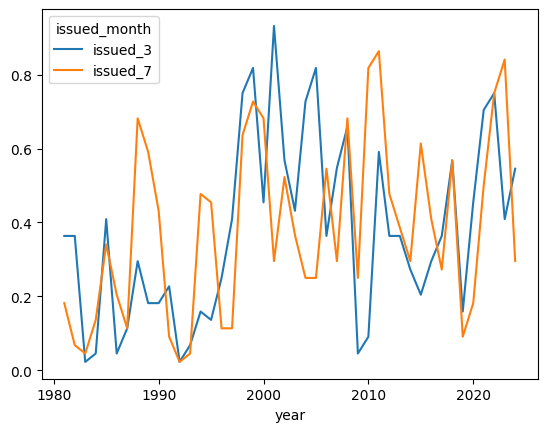

In [20]:
df_pivot.plot(x="year", y=["issued_3", "issued_7"])

In [21]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot.index)
    model = sm.OLS(df_pivot[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     7.138
Date:                Tue, 11 Mar 2025   Prob (F-statistic):             0.0107
Time:                        10:33:12   Log-Likelihood:                 3.0037
No. Observations:                  44   AIC:                            -2.007
Df Residuals:                      42   BIC:                             1.561
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2183      0.069     

Same as for absolute values -
as a crude check, we see that the confidence intervals for the slope are
positive. So we can try to filter to more recent years to hopefully
make it trendless.

In [22]:
min_year = 2001
df_pivot_recent = df_pivot[df_pivot["year"] >= min_year]

<Axes: xlabel='year'>

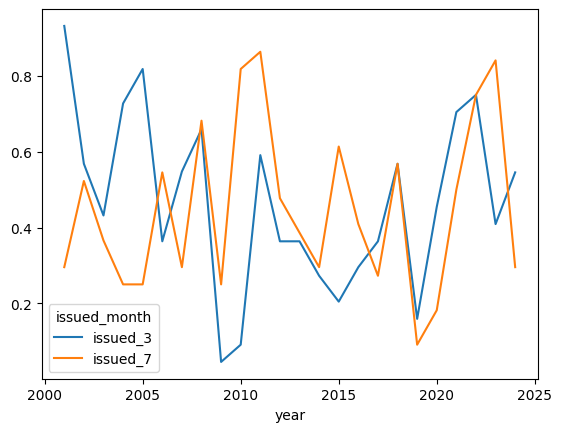

In [23]:
df_pivot_recent.plot(x="year", y=["issued_3", "issued_7"])

In [24]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot_recent.index)
    model = sm.OLS(df_pivot_recent[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.012
Date:                Tue, 11 Mar 2025   Prob (F-statistic):              0.325
Time:                        10:33:13   Log-Likelihood:                 2.1718
No. Observations:                  24   AIC:                           -0.3435
Df Residuals:                      22   BIC:                             2.013
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6836      0.220     

Confidence intervals of slope span 0 now, so we're good.

In [25]:
df_pivot_recent

issued_month,year,issued_3,issued_7
20,2001,0.931818,0.295455
21,2002,0.568182,0.522727
22,2003,0.431818,0.365909
23,2004,0.727273,0.250000
24,2005,0.818182,0.250000
25,2006,0.363636,0.545455
26,2007,0.547727,0.295455
27,2008,0.659091,0.681818
28,2009,0.045455,0.250000
29,2010,0.090909,0.818182


### Plot historical activations

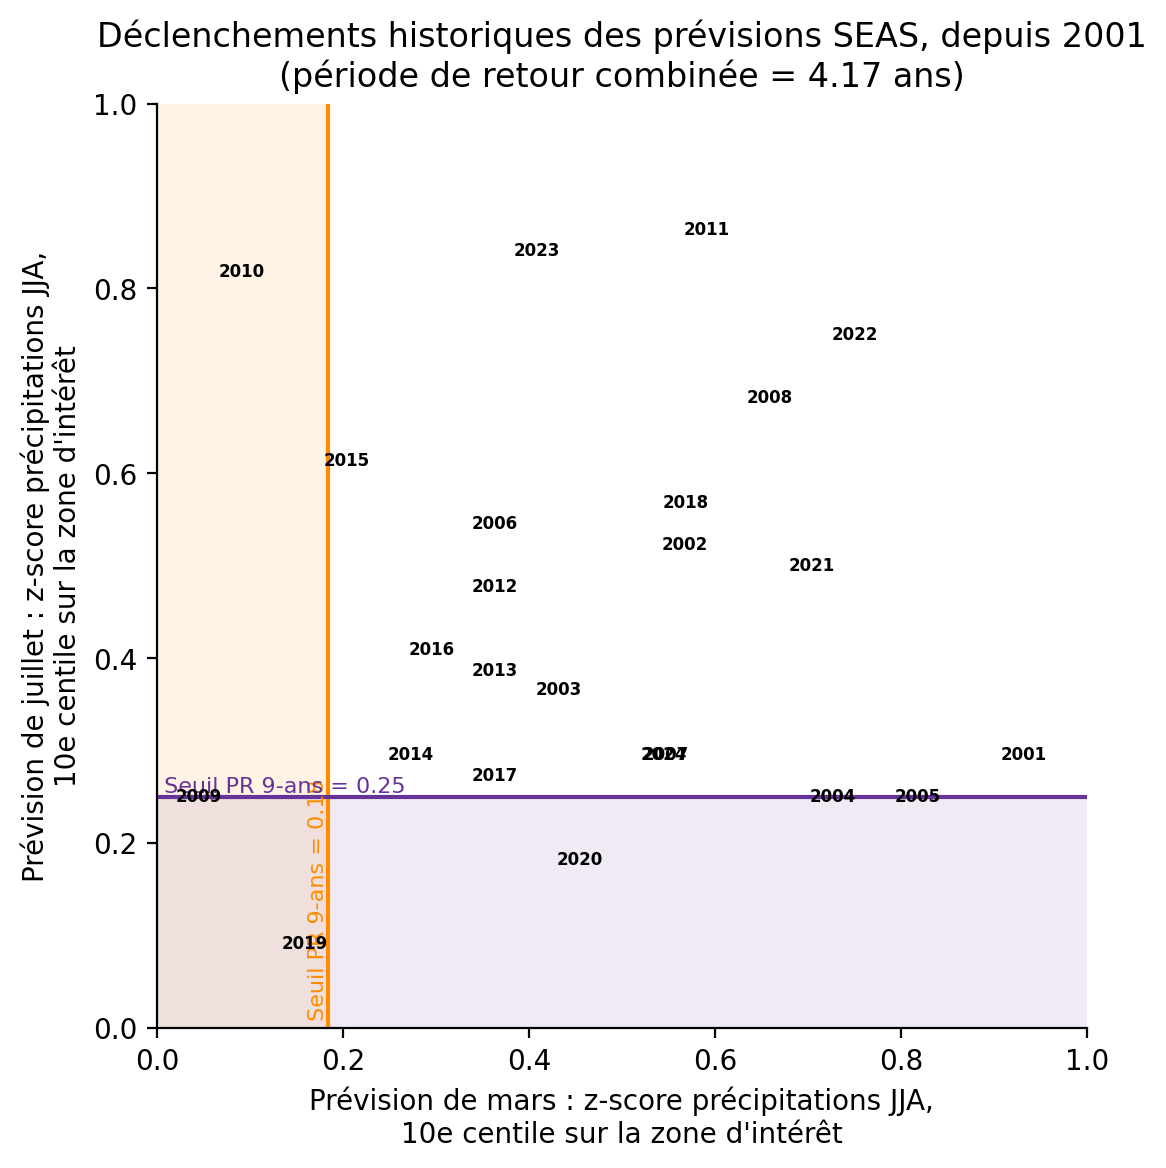

In [26]:
rp_individual_seas5 = 9

thresh_3 = df_pivot_recent["issued_3"].quantile(1 / rp_individual_seas5)
thresh_7 = df_pivot_recent["issued_7"].quantile(1 / rp_individual_seas5)

rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

# min_val = -0.19
# max_val = 0.11
min_val, max_val = 0, 1
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.1

color_3 = "darkorange"
ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_3:.2f}",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

color_7 = "rebeccapurple"
ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_7:.2f}",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

ax.set_xlabel(
    "Prévision de mars : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Fixing thresholds based on proposed values for framework. We are fixing the same value for both months for a couple reasons:

- We can't really say whether the spatial quantile values we're plotting have a different distribution from issue month to issue month, so it doesn't really make sense to fix the threshold independently for each one.
- Having the same threshold for each month is just easier to remember and easier to explain.
- Also, conveniently, the threshold that corresponds to the requested forecast RP (around 6 years combined), is 20th, which is the lower quintile

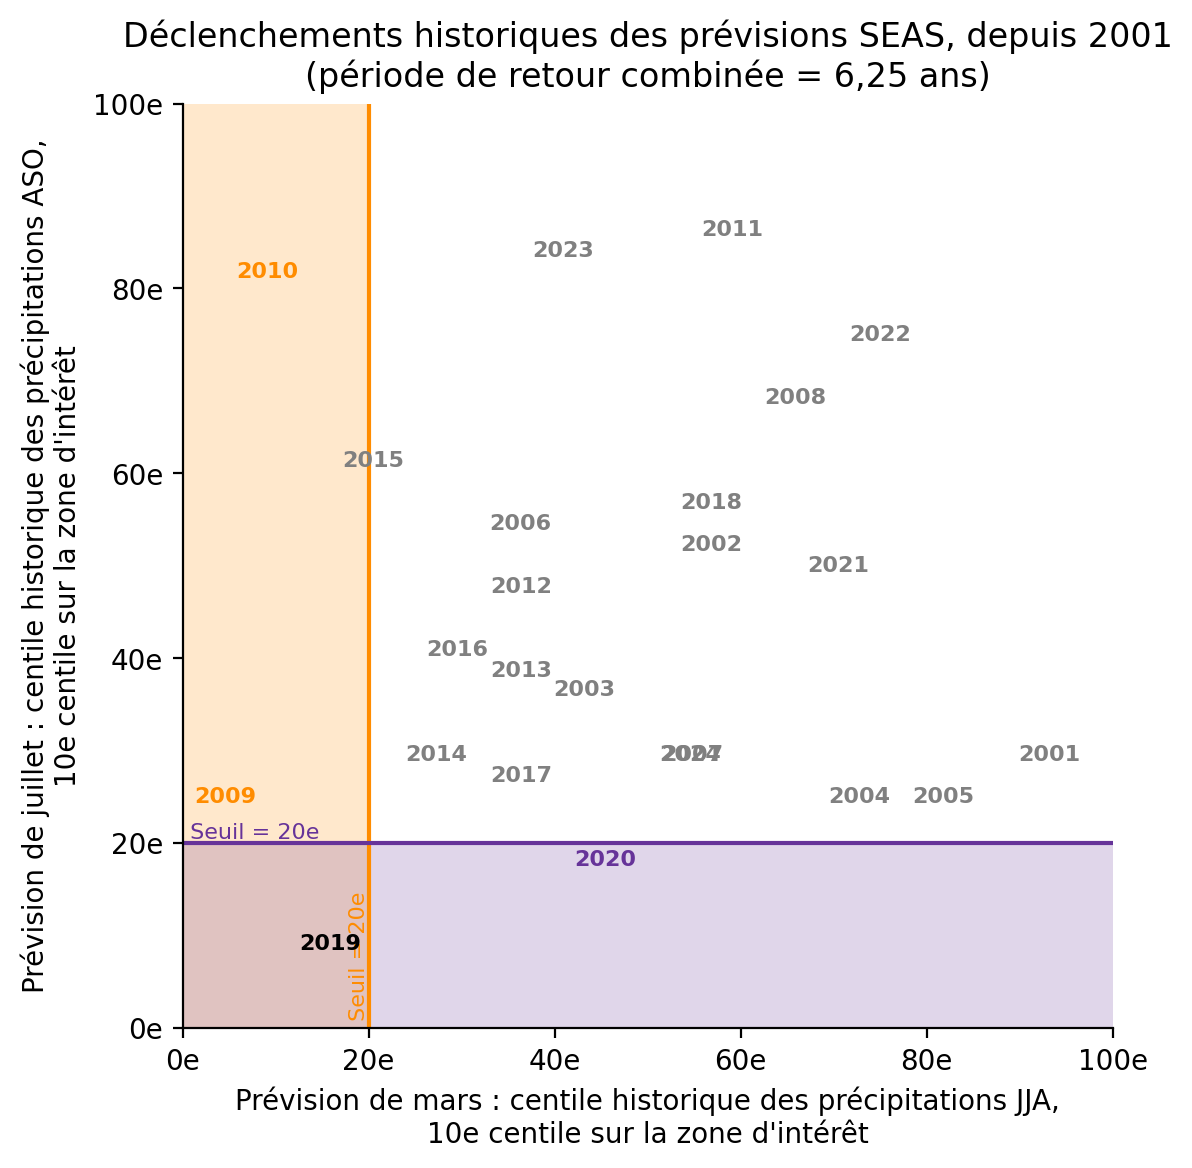

In [34]:
# thresh_3 = -0.9
# thresh_7 = -0.66
thresh_3 = 0.2
thresh_7 = thresh_3


rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

# min_val = -2.2
# max_val = 1.5
min_val, max_val = 0, 1
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.2

color_3 = "darkorange"
color_7 = "rebeccapurple"

ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil = {thresh_3* 100:.0f}e",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil = {thresh_7* 100:.0f}e",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    if (row["issued_3"] < thresh_3) & (row["issued_7"] < thresh_7):
        color = "black"
    elif row["issued_3"] < thresh_3:
        color = color_3
    elif row["issued_7"] < thresh_7:
        color = color_7
    else:
        color = "grey"
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color=color,
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))


# Custom formatter for the ticks
def custom_percentage_formatter(x, pos):
    return f"{x * 100:.0f}e"  # Multiplies by 100 and appends 'e'


ax.xaxis.set_major_formatter(FuncFormatter(custom_percentage_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(custom_percentage_formatter))

ax.set_xlabel(
    "Prévision de mars : centile historique des précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : centile historique des précipitations ASO,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)".replace(".", ",")
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [45]:
(2024 - 2001 + 1) * 2

48

In [48]:
((2024 - 2001 + 1) * 2 + 1) / 5

9.8